In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

### Read Decision Forests Results

In [4]:
Ts_DF = [0]+[2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/DF/RF_oh_w_time0_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_DF):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)

#PREWARDS = []
#PREGRETS = []
#for rep in range(10):
#    fn = f"../results/PAFM/DF/RF_optimal_oh_w_time128_2048_lookahead{step}_reps{rep}.npz"
#    data = np.load(fn)
#    states = data["future_states"]
#    prewards = []
#    pregrets = []
#    for k,T in enumerate(Ts_DF):
#        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
#        preward = compute_normalized_future_rewards(irewards,100,0.5)
#        path, ireward_opt = path_opt(states[k,0], T, 100)
#        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
#        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
#        prewards.append(np.sum(preward).item())
#        pregrets.append(pregret)
#    PREWARDS.append(prewards)
#    PREGRETS.append(pregrets)
#    PREWARDS_arr = np.vstack(PREWARDS)
#    PREGRETS_PAFM_DF_opt_arr = np.vstack(PREGRETS)
#print(PREGRETS_PAFM_DF_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 14)


### Read Neural Net Results

In [9]:
Ts_NN = [0,128,256,512]+[750]+[1024,1250,1500,2048]

step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/NN/NN_onehot_w_lookahead_with_t0_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_NN):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_NN_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_NN_arr.shape)

#PREWARDS = []
#PREGRETS = []
#for rep in range(1):
#    fn = f"../results/PAFM/NN/NN_oracle_w_lookahead_PAFM.npz"
#    data = np.load(fn)
#    states = data["future_states"]
#    prewards = []
#    pregrets = []
#    for k,T in enumerate(Ts_NN):
#        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
#        preward = compute_normalized_future_rewards(irewards,100,0.5)
#        path, ireward_opt = path_opt(states[k,0], T, 100)
#        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
#        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
#        prewards.append(np.sum(preward).item())
#        pregrets.append(pregret)
#    PREWARDS.append(prewards)
#    PREGRETS.append(pregrets)
#    PREWARDS_arr = np.vstack(PREWARDS)
#    PREGRETS_PAFM_NN_opt_arr = np.vstack(PREGRETS)
#print(PREGRETS_PAFM_NN_opt_arr.shape)
# PREGRETS_PAFM_DF_arr

(10, 9)


# Read RL baseline

In [11]:
fn = f"../results/RL/pregret_fqi_notime.npz"
data = np.load(fn)
data['pregret_list']

array([1.02055431, 1.2008456 , 1.18411001, 1.18927797, 1.19613473,
       1.18778069, 1.1278969 , 1.18778069])

In [10]:
PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_fqi_notime.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_FQI_notime = np.vstack(PREGRETS)


PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_fqi_time.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_FQI_time = np.vstack(PREGRETS)


PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_harmonic_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_hmn_time = np.vstack(PREGRETS)


PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_known_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_period = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_unknown_period.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_time = np.vstack(PREGRETS)

PREWARDS = []
PREGRETS = []
fn = f"../results/RL/pregret_tabql_notime.npz"
data = np.load(fn)
pregrets = data["pregret_list"]
PREGRETS.append(pregrets)
PREGRETS_TQL_notime = np.vstack(PREGRETS)


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_84172/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


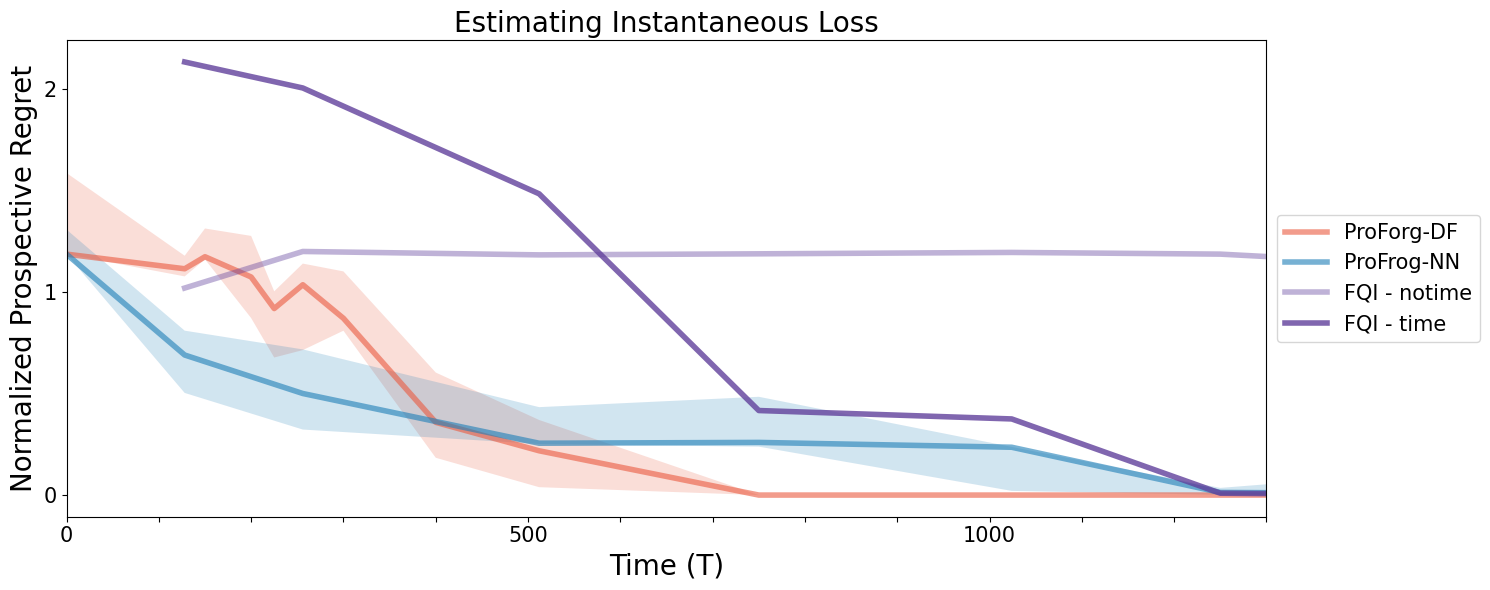

In [12]:
plt.figure(figsize=(15, 6))
linewidth = 4
fontsize = 20

pafm_df, pafm_df_opt = get_close_colors("OrRd", start = 0.65, delta = 0.3, n = 2) 
pafm_nn, pafm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
rl_fqi,_ = get_close_colors("Purples", start=0.8, delta=0.5,n = 2)
rl_tql,_ = get_close_colors("Greens", start=0.6, delta=0.5,n = 2)
colors = {"PAFM_oh_RF": pafm_df,
          "PAFM_opt_RF":pafm_df,
          "PAFM_oh_NN": pafm_nn,
          "PAFM_opt_NN":pafm_nn,
          "RL_FQI":rl_fqi,
          "RL_TQL":rl_tql
          }

## Plot DF
median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
plt.plot(Ts_DF, median,color=colors["PAFM_oh_RF"], lw = linewidth,alpha = 0.6,label = 'ProForg-DF')
plt.fill_between(Ts_DF, q25, q75, color=colors["PAFM_oh_RF"], alpha=0.20, edgecolor="none")


#median = np.min(PREGRETS_PAFM_DF_opt_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_DF_opt_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_DF_opt_arr, 75, axis=0)
#plt.plot(Ts_DF, median,color=colors["PAFM_opt_RF"], lw = linewidth,alpha = 0.6,label = 'ProForg-Oracle-DF',marker='o',linestyle = '--')
# plt.fill_between(Ts, q25, q75, color=colors["PAFM_opt_RF"], alpha=0.25, edgecolor="none")

## Plot NN
median = np.median(PREGRETS_PAFM_NN_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_NN_arr, 75, axis=0)
plt.plot(Ts_NN, median,color=colors["PAFM_oh_NN"], lw = linewidth,alpha = 0.6,label = 'ProFrog-NN')
plt.fill_between(Ts_NN, q25, q75, color=colors["PAFM_oh_NN"], alpha=0.20, edgecolor="none")


#median = np.min(PREGRETS_PAFM_NN_opt_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_NN_opt_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_NN_opt_arr, 75, axis=0)
# plt.plot(Ts_NN, median,color=colors["PAFM_opt_NN"], lw = linewidth,alpha = 0.6,label = 'ProForg-Oracle-NN',marker='o',linestyle = '--')
# plt.fill_between(Ts, q25, q75, color=colors["PAFM_oh_NN"], alpha=0.25, edgecolor="none")

Ts_NN = [128,256,512]+[750]+[1024,1250,1500,2048]
## Plot RL:
plt.plot(Ts_NN, PREGRETS_FQI_notime.reshape(-1,1),color=colors["RL_FQI"], lw = linewidth,alpha = 0.4,label = 'FQI - notime')
plt.plot(Ts_NN, PREGRETS_FQI_time.reshape(-1,1),color=colors["RL_FQI"], lw = linewidth,alpha = 0.8,label = 'FQI - time')


# plt.plot(Ts_NN, PREGRETS_TQL_notime.reshape(-1,1),color=colors["RL_TQL"], lw = linewidth,alpha = 0.2,label = 'ProFrog-TabQL - notime',marker='o')
# plt.plot(Ts_NN, PREGRETS_TQL_time.reshape(-1,1),color=colors["RL_TQL"], lw = linewidth,alpha = 0.4,label = 'ProFrog-TabQL - time',marker='o')
# plt.plot(Ts_NN, PREGRETS_TQL_period.reshape(-1,1),color=colors["RL_TQL"], lw = linewidth,alpha = 0.6,label = 'ProFrog-TabQL - period+time',marker='o')
# plt.plot(Ts_NN, PREGRETS_TQL_hmn_time.reshape(-1,1),color=colors["RL_TQL"], lw = linewidth,alpha = 0.8,label = 'ProFrog-TabQL - harmonic_period+time',marker='o')


plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
#plt.xscale('log')

xticks = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300]
xticklabels = [0,"", "", "", "", 500, "", "", "", "", 1000, "", "", ""]

plt.xlim(0, 1300)


plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)

# plt.xticks(Ts_PAFM+Ts_PVFM, labels=[str(v) for v in Ts_PAFM+Ts_PVFM])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.title('Estimating Instantaneous Loss',fontsize = fontsize)
# plt.xlim(0,700000)                  
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5),fontsize = fontsize-5)
#plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()